# **KERAS**
Keras originally appeared as a wrapper to make multiple deep learning frameworks such as Theano and TensorFlow easier to use. Keras makes it easy to build neural networks without specialized knowledge. Currently, it can be used directly as a high-level API for TensorFlow and is used for many purposes.

A wrapper is something that uses the functions of an existing program while providing a mechanism to make it easier to use. For example, TensorFlow has powerful neural network calculation functions, but using it as is can be quite tedious. To solve this, Keras wraps the functions of TensorFlow, making it easier to use.

A high-level API is a set of functions that are grouped together in large units to make programming easier. For example, Keras, which is part of the high-level API provided by TensorFlow, makes building and training neural networks very intuitive. In contrast, there are also low-level APIs that require control of functions at small units, which require more fine-grained control and optimization.

In the first half, we will run a TensorFlow example. In the second half, we will write Keras code.

Deep learning frameworks officially publish example code for various models.

# Problem 1: Share and run the official tutorial model
Share and run the official TensorFlow tutorial models.

In [1]:
import tensorflow as tf
from tensorflow import keras
# Using MNIST dataset
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

model = tf.keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax) ])


2025-04-26 12:36:44.519469: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745671004.802448      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745671004.887216      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-04-26 12:37:02.857653: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


summary Methods provide an overview of the model you have created , which is particularly useful when debugging and tuning your model.

In [2]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

When compiling a model, we specify a loss function, optimization method, and evaluation metric, for example for binary classification sparse_categorical_crossentropy.

In [3]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # from_logits=False is the default
    metrics=['accuracy'])

Next, we train the model. It is important to choose an appropriate number of epochs to check the model's performance during training or to stop it early.

In [4]:
model.fit(x_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8747 - loss: 0.4340
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9630 - loss: 0.1242
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9779 - loss: 0.0742
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9830 - loss: 0.0554
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0432


After training, we estimate the model and evaluate the prediction results to determine whether the training was successful.

In [5]:
import numpy as np
y_pred_proba = model.predict(x_train) # for each class

y_pred = np.argmax(y_pred_proba, axis=1) # class with highest probability

print("y_pred_proba shape", y_pred_proba.shape)
print("y_pred", y_pred)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
y_pred_proba shape (60000, 10)
y_pred [5 0 4 ... 5 6 8]


evaluateMethods are useful if we just want to evaluate .

In [6]:
score = model.evaluate(x_train, y_train, verbose=0)
print('Train loss:', score[0])
print('Train accuracy:', score[1])

Train loss: 0.02933928370475769
Train accuracy: 0.9919166564941406


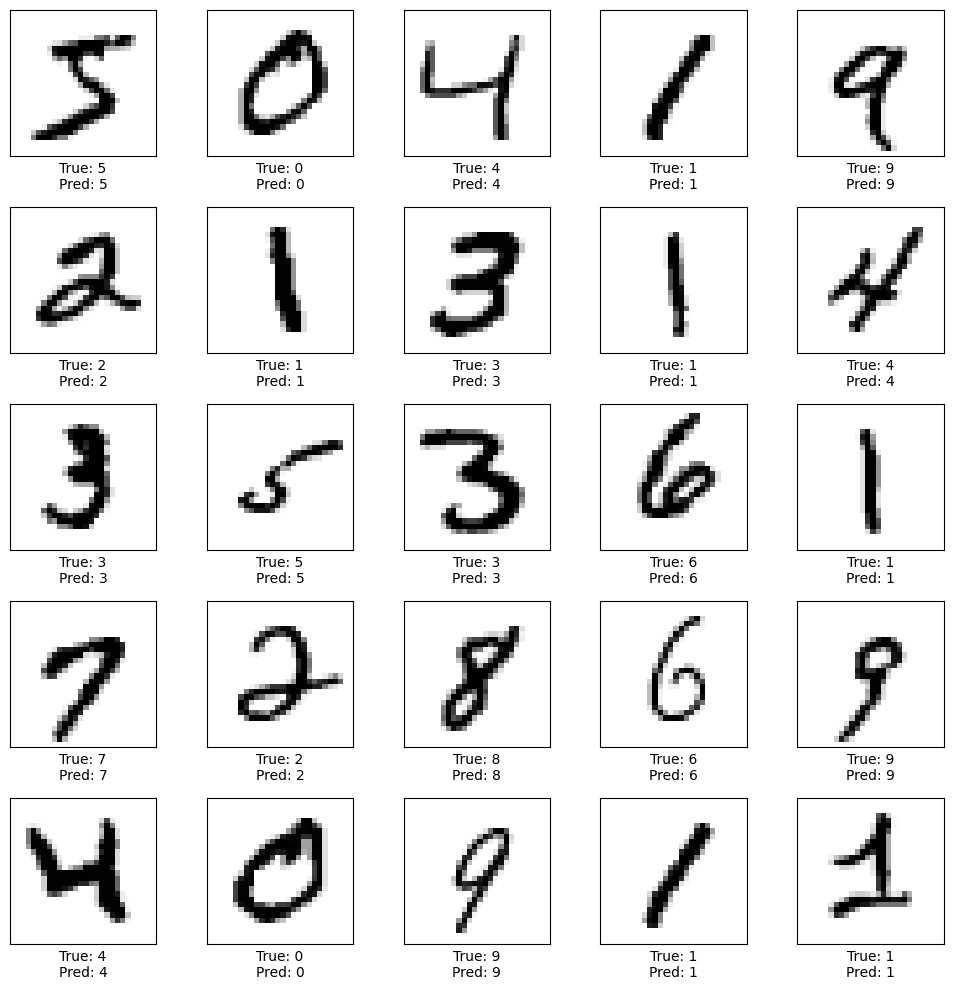

In [7]:
# Plot to visualize
import matplotlib.pyplot as plt

# Let's plot the first 25 images and their predicted labels
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])  # no x ticks
    plt.yticks([])  # no y ticks
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(f"True: {y_train[i]}\nPred: {y_pred[i]}")
plt.tight_layout()
plt.show()

# Problem 2: (Advanced problem) Implement various methods
The GitHub repositories of TensorFlow and Google AI Research contain a wide variety of code, from classic models to the latest models. We choose pretrained EfficientNetB0 model from the official TensorFlow Models Github repository. It is a family of convolutional neural networks developed by Google I research.

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1: African_elephant (0.39)
2: Indian_elephant (0.32)
3: tusker (0.14)


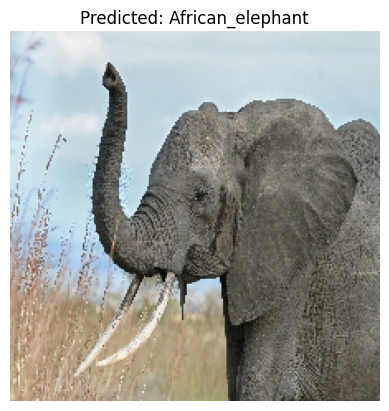

In [8]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input, decode_predictions
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load the EfficientNetB0 model pretrained on ImageNet
model = EfficientNetB0(weights='imagenet')

import urllib.request

# Download a sample image (elephant) if it doesn't exist
img_url = "https://upload.wikimedia.org/wikipedia/commons/6/63/African_elephant_warning_raised_trunk.jpg"
img_path = "elephant.jpg"
urllib.request.urlretrieve(img_url, img_path)

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Predict the class
preds = model.predict(x)
decoded_preds = decode_predictions(preds, top=3)[0]

# Output predictions
for idx, (imagenet_id, label, score) in enumerate(decoded_preds):
    print(f"{idx + 1}: {label} ({score:.2f})")

# Display the image
plt.imshow(img)
plt.title(f"Predicted: {decoded_preds[0][1]}")
plt.axis('off')
plt.show()

We will convert the TensorFlow code that handles four types of datasets created in "Sprint13 TensorFlow" into a different framework.

- Iris (binary classification of Iris-versicolor and Iris-virginica only)
- Iris (multiple classification using all three types of objective variables)
- House Prices
- MNIST

Converting to Keras: For Keras, we use the tf.keras module included in TensorFlow. Keras has various ways of writing, such as a Sequential model or a Functional API, but this is not specified.

# Problem 3: Learning Iris (binary classification) with Keras
We rewrite the TensorFlow binary classification for the Iris dataset in Keras.

In [9]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Only select Versicolor (class 1) and Virginica (class 2)
binary_indices = np.where((y == 1) | (y == 2))
X = X[binary_indices]
y = y[binary_indices]

# Relabel: Versicolor (1) -> 0, Virginica (2) -> 1
y = y - 1

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Build the Keras model
model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

# 5. Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=4, validation_split=0.2)

# 7. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# 8. Predict
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print("Predicted probabilities:\n", y_pred_proba.flatten())
print("Predicted labels:\n", y_pred.flatten())
print("True labels:\n", y_test)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3844 - loss: 0.8539 - val_accuracy: 0.3750 - val_loss: 0.7975
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4173 - loss: 0.7887 - val_accuracy: 0.3750 - val_loss: 0.7720
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4526 - loss: 0.7328 - val_accuracy: 0.3125 - val_loss: 0.7488
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3960 - loss: 0.7518 - val_accuracy: 0.3750 - val_loss: 0.7299
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4440 - loss: 0.6575 - val_accuracy: 0.4375 - val_loss: 0.7121
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5015 - loss: 0.6643 - val_accuracy: 0.5000 - val_loss: 0.6965
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5112 - loss: 0.6371 - val_accuracy: 0.5000 - val_loss: 0.6821
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6873 - loss: 0.5885 - val_accuracy: 0.5625 - val_loss

# Problem 4: Learning Iris (multi-class classification) with Keras
We rewrite the TensorFlow ternary classification for the Iris dataset in Keras.

In [10]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Load the full Iris dataset
iris = load_iris()
X = iris.data
y = iris.target  # 0 = setosa, 1 = versicolor, 2 = virginica

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Build the Keras model
model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    keras.layers.Dense(3, activation='softmax')  # 3 classes
])

model.summary()

# 5. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # multi-class classification
    metrics=['accuracy']
)

# 6. Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=4, validation_split=0.2)

# 7. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# 8. Predict
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Predicted class probabilities:\n", y_pred_proba)
print("Predicted labels:\n", y_pred)
print("True labels:\n", y_test)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2663 - loss: 1.1283 - val_accuracy: 0.5417 - val_loss: 1.0136
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5145 - loss: 1.0144 - val_accuracy: 0.5833 - val_loss: 0.9175
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5425 - loss: 0.9102 - val_accuracy: 0.6250 - val_loss: 0.8376
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5414 - loss: 0.8390 - val_accuracy: 0.6667 - val_loss: 0.7706
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5705 - loss: 0.7578 - val_accuracy: 0.6667 - val_loss: 0.7177
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6291 - loss: 0.6860 - val_accuracy: 0.7500 - val_loss: 0.6719
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7294 - loss: 0.6124 - val_accuracy: 0.7500 - val_loss: 0.6355
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7142 - loss: 0.6269 - val_accuracy: 0.7083 - val_loss

# Problem 5: Learning House Prices with Keras
Translate the TensorFlow regression on the House Prices dataset into Keras.

In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Kaggle House Prices dataset
df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# 2. Basic preprocessing
# Drop columns with too many missing values
df = df.drop(columns=["Alley", "PoolQC", "Fence", "MiscFeature", "FireplaceQu"])  

# Fill missing numeric columns with mean
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill missing categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# One-hot encode categorical variables
df = pd.get_dummies(df)

# 3. Prepare features and target
X = df.drop('SalePrice', axis=1).values
y = df['SalePrice'].values

# 4. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Build the Keras model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)  # Regression output
])

model.summary()

# 7. Compile the model
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error
)

# 8. Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# 9. Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f'Test Loss (MSE): {loss:.2f}')
print(f'Test MAE: {mae:.2f}')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 128)                 │          34,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,009 (168.00 KB)

 Trainable params: 43,009 (168.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 37961314304.0000 - mae: 180438.0312 - val_loss: 37838569472.0000 - val_mae: 181093.4062
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 42120388608.0000 - mae: 187350.6875 - val_loss: 37824462848.0000 - val_mae: 181062.0781
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40393347072.0000 - mae: 183272.9531 - val_loss: 37778087936.0000 - val_mae: 180961.2031
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38377447424.0000 - mae: 180059.5000 - val_loss: 37665619968.0000 - val_mae: 180716.8594
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40130203648.0000 - mae: 183173.1719 - val_loss: 37453897728.0000 - val_mae: 180252.8750
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39665430528.0000 - mae: 182048.7188 - val_loss: 37102465024.0000 - val_mae: 179477.1250
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37826351104.0000 - mae: 177286.2188 - val_loss: 36583755776.0000 

#  Problem 6: Learning MNIST with Keras
We rewrite the TensorFlow multi-class image classification using the MNIST dataset in Keras.

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. Load MNIST dataset
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Normalize the pixel values (0~255 -> 0~1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. Build the Keras model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Flatten 28x28 into 784
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  # 10 classes (digits 0-9)
])

model.summary()

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# 6. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# 7. Predict
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("First 10 Predicted Labels:", y_pred[:10])
print("First 10 True Labels:", y_test[:10])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8725 - loss: 0.4476 - val_accuracy: 0.9662 - val_loss: 0.1252
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9660 - loss: 0.1192 - val_accuracy: 0.9740 - val_loss: 0.0952
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9763 - loss: 0.0802 - val_accuracy: 0.9772 - val_loss: 0.0835
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9811 - loss: 0.0589 - val_accuracy: 0.9758 - val_loss: 0.0845
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9864 - loss: 0.0465 - val_accuracy: 0.9787 - val_loss: 0.0790
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9730 - loss: 0.0830
Test Loss: 0.0721
Test Accuracy: 0.9767
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
First 10 Predicted Labels: [7 2 1 0 4 1 4 9 6 9]
First 10 True Labels: [7 2 1 0 4 1 4 9 5 9]


# Problem 7: (Advanced assignment) Rewriting to PyTorch
Rewrite the four types of problems in PyTorch.

In [13]:
# Iris Binary Classification
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
y = (y == 1).astype(int)  # We are doing binary classification for Iris-versicolor vs Iris-virginica

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocessing: standardizing the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 5. Build the model
class IrisModel(nn.Module):
    def __init__(self):
        super(IrisModel, self).__init__()
        self.fc1 = nn.Linear(4, 64)  # Input has 4 features
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = IrisModel()

# 6. Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 7. Train the model
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_tensor).squeeze()
    loss = criterion(y_pred, y_train_tensor.float())
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

# 8. Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).squeeze()
    y_pred_class = (y_pred > 0.5).long()
    accuracy = (y_pred_class == y_test_tensor).float().mean()
    print(f'Test Accuracy: {accuracy.item() * 100:.2f}%')

Epoch 0, Loss: 0.6684076189994812
Epoch 10, Loss: 0.6199899315834045
Epoch 20, Loss: 0.5813060998916626
Epoch 30, Loss: 0.5495846271514893
Epoch 40, Loss: 0.5219452977180481
Test Accuracy: 80.00%


In [14]:
# Iris MultiClass Classification
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocessing: standardizing the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 5. Build the model
class IrisModel(nn.Module):
    def __init__(self):
        super(IrisModel, self).__init__()
        self.fc1 = nn.Linear(4, 64)
        self.fc2 = nn.Linear(64, 3)  # 3 classes for Iris dataset
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.softmax(x)
        return x

model = IrisModel()

# 6. Loss and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 7. Train the model
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

# 8. Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_class = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_class == y_test_tensor).float().mean()
    print(f'Test Accuracy: {accuracy.item() * 100:.2f}%')

Epoch 0, Loss: 1.154201865196228
Epoch 10, Loss: 1.0916332006454468
Epoch 20, Loss: 1.02708899974823
Epoch 30, Loss: 0.9645755290985107
Epoch 40, Loss: 0.9104772210121155
Test Accuracy: 83.33%


In [15]:
# House Prices Dataset
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Kaggle House Prices dataset
df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# 2. Preprocessing: Handle missing data and one-hot encoding
df = df.drop(columns=["Alley", "PoolQC", "Fence", "MiscFeature", "FireplaceQu"])  # Drop columns with too many missing values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
df = pd.get_dummies(df)

# 3. Prepare features and target
X = df.drop('SalePrice', axis=1).values
y = df['SalePrice'].values

# 4. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# 7. Build the model
class HousePricesModel(nn.Module):
    def __init__(self):
        super(HousePricesModel, self).__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 128)
        self.fc2 = nn.Linear(128, 1)  # Regression output

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = HousePricesModel()

# 8. Loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 9. Train the model
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

# 10. Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    loss = criterion(y_pred, y_test_tensor)
    print(f'Test Loss: {loss.item()}')

Epoch 0, Loss: 38885531648.0
Epoch 10, Loss: 38885142528.0
Epoch 20, Loss: 38884577280.0
Epoch 30, Loss: 38883794944.0
Epoch 40, Loss: 38882729984.0
Epoch 50, Loss: 38881341440.0
Epoch 60, Loss: 38879580160.0
Epoch 70, Loss: 38877396992.0
Epoch 80, Loss: 38874746880.0
Epoch 90, Loss: 38871597056.0
Test Loss: 39636013056.0


In [16]:
# MNIST Classification
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# 1. Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

# 2. Build the model
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)  # Flatten input to 784
        self.fc2 = nn.Linear(128, 10)  # 10 classes for digits 0-9

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MNISTModel()

# 3. Loss and optimizer
criterion = nn.CrossEntropyLoss()  # Multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Train the model
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

# 5. Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 53.3MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.48MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch 1, Loss: 0.3819157581673121
Epoch 2, Loss: 0.1960720728947791
Epoch 3, Loss: 0.14178733794943993
Epoch 4, Loss: 0.11454478681170896
Epoch 5, Loss: 0.0986627630327445
Test Accuracy: 96.83%


# Problem 8: (Advanced assignment) Comparing frameworks
We summarize the differences between each framework.

1. Calculation Speed
TensorFlow is generally the fastest, especially when utilizing TPUs. Keras's speed is similar to TensorFlow but with some overhead due to abstraction. PyTorch can be slower in some cases due to its dynamic nature but is highly flexible.

3. Number of lines of code/readability
Keras is the most readable with minimal code, ideal for quick development and beginner-friendly. PyTorch is also quite readable and clean for custom models, with a pythonic approach that aligns closely with standard Python programming. TensorFlow is more verbose and complex, especially when building custom models

4. Available features
TensorFlow has the most comprehensive features, especially for production and deployment. Keras focuses on ease of use, and while great for model building, it has fewer deployment tools. PyTorch has great features for research and experimentation but is still catching up on deployment tools.

5. Community Ecosystem
TensorFlow has the largest community and the most mature ecosystem, especially for deployment. Keras benefits from TensorFlow’s ecosystem but has a smaller independent community. PyTorch is growing quickly in the research space, and the community is very supportive, but it’s still catching up in industry applications.